# ElectInfo visualizes dem share × turnout as a bivariate choropleth

## What this shows
Consumes the precinct-keyed DataFrame from `spatial/05_multi_source_joins.ipynb` and renders it as a bivariate choropleth — one visualization encoding two metrics (Democratic share + turnout %) via a 2D color grid. This is the ElectInfo canonical deliverable for precinct-level analysis.

## Why it matters
Univariate choropleths waste ink — if you want to show "where is support high AND turnout high?", a bivariate choropleth answers it in one look. ElectInfo's maps almost always end up in this format for client decks.

## Prereqs
- `pip install 'siege-utilities[geo,reporting]'`
- No credentials; geometry is a small synthetic 8-precinct layout.

## Next
- `reports/01_charts_and_pdf.ipynb` — the PDF surface that embeds this map.
- `spatial/04_redistricting.ipynb` — compare the TX-32 polygons across redistricting cycles.


## 1. Synthetic precinct polygons + the unified DataFrame

Rebuild the unified DataFrame from `spatial/05` (3 vendor sources → one precinct-keyed table) and attach simple square polygons so the map renders without needing the live TIGER download.

In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon

# 4x2 grid of square precincts
precincts = []
for i in range(8):
    col = i % 4
    row = i // 4
    precincts.append({
        'precinct_id': f'TX32-{i+1:03d}',
        'geometry':     Polygon([(col, row), (col+1, row), (col+1, row+1), (col, row+1)]),
    })
gdf = gpd.GeoDataFrame(precincts, crs='EPSG:4326')

unified = pd.DataFrame({
    'precinct_id': [f'TX32-{i:03d}' for i in range(1, 9)],
    'dem_pct':     [0.62, 0.58, 0.71, 0.48, 0.41, 0.55, 0.52, 0.65],
    'turnout_pct': [0.49, 0.51, 0.58, 0.42, 0.39, 0.48, 0.46, 0.55],
})

gdf = gdf.merge(unified, on='precinct_id')
gdf


,precinct_id,geometry,dem_pct,turnout_pct
0,TX32-001,"POLYGON ((0.00000 0.00000, 1.00000 0.00000, 1....",0.62,0.49
1,TX32-002,"POLYGON ((1.00000 0.00000, 2.00000 0.00000, 2....",0.58,0.51
2,TX32-003,"POLYGON ((2.00000 0.00000, 3.00000 0.00000, 3....",0.71,0.58
3,TX32-004,"POLYGON ((3.00000 0.00000, 4.00000 0.00000, 4....",0.48,0.42
4,TX32-005,"POLYGON ((0.00000 1.00000, 1.00000 1.00000, 1....",0.41,0.39
5,TX32-006,"POLYGON ((1.00000 1.00000, 2.00000 1.00000, 2....",0.55,0.48
6,TX32-007,"POLYGON ((2.00000 1.00000, 3.00000 1.00000, 3....",0.52,0.46
7,TX32-008,"POLYGON ((3.00000 1.00000, 4.00000 1.00000, 4....",0.65,0.55


## 2. Classify each precinct into a 3×3 bivariate bin

The canonical bivariate scheme: tertiles of metric A × tertiles of metric B, giving nine categories. Then map each category to one of a 3×3 color grid.

In [2]:
import numpy as np

def tertile(values):
    q1, q2 = values.quantile([1/3, 2/3])
    return values.apply(lambda v: 0 if v < q1 else (1 if v < q2 else 2)).astype(int)

gdf['dem_bin']     = tertile(gdf['dem_pct'])
gdf['turnout_bin'] = tertile(gdf['turnout_pct'])
gdf['biv_class']   = gdf['dem_bin'] * 3 + gdf['turnout_bin']
gdf[['precinct_id', 'dem_pct', 'turnout_pct', 'dem_bin', 'turnout_bin', 'biv_class']]


,precinct_id,dem_pct,turnout_pct,dem_bin,turnout_bin,biv_class
0,TX32-001,0.62,0.49,2,1,7
1,TX32-002,0.58,0.51,1,2,5
2,TX32-003,0.71,0.58,2,2,8
3,TX32-004,0.48,0.42,0,0,0
4,TX32-005,0.41,0.39,0,0,0
5,TX32-006,0.55,0.48,1,1,4
6,TX32-007,0.52,0.46,0,0,0
7,TX32-008,0.65,0.55,2,2,8


## 3. Render the bivariate map

A 3×3 palette where rows vary by dem share and columns by turnout. High-support × high-turnout precincts end up in one corner (the strongest signal), low × low in the other.

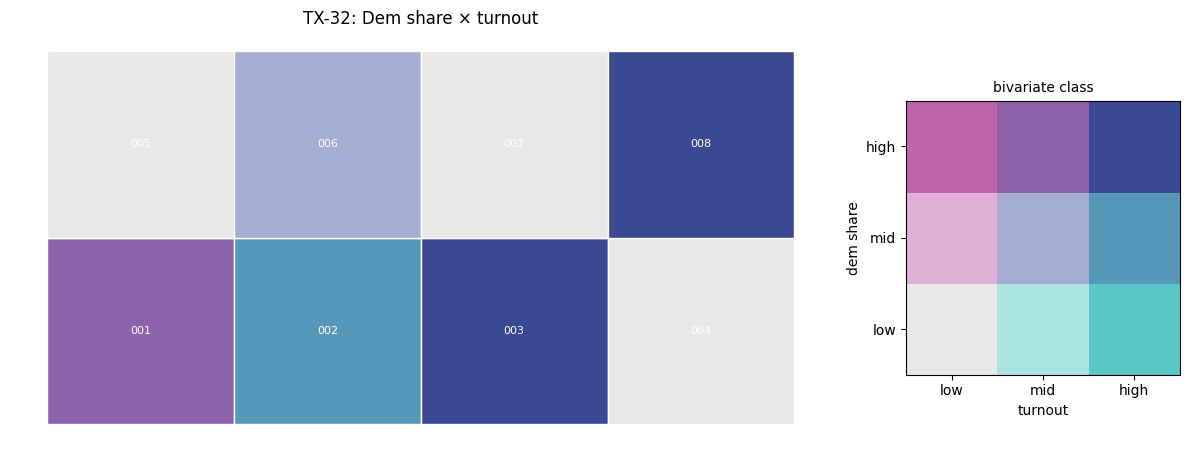

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 3x3 bivariate palette (rows: dem, cols: turnout), hand-picked for legibility.
biv_palette = [
    '#e8e8e8', '#ace4e4', '#5ac8c8',   # low dem
    '#dfb0d6', '#a5add3', '#5698b9',   # mid dem
    '#be64ac', '#8c62aa', '#3b4994',   # high dem
]
cmap = mcolors.ListedColormap(biv_palette)

fig, (ax_map, ax_leg) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 1]})

gdf.plot(column='biv_class', cmap=cmap, vmin=0, vmax=8,
         edgecolor='white', linewidth=1.0, ax=ax_map)
for _, r in gdf.iterrows():
    ax_map.annotate(r['precinct_id'][-3:], xy=r.geometry.centroid.coords[0],
                    ha='center', va='center', fontsize=8, color='white')
ax_map.set_title('TX-32: Dem share × turnout')
ax_map.set_axis_off()

# 3x3 legend
leg = np.arange(9).reshape(3, 3)
ax_leg.imshow(leg, cmap=cmap, vmin=0, vmax=8, origin='lower')
ax_leg.set_xticks([0, 1, 2], ['low', 'mid', 'high'])
ax_leg.set_yticks([0, 1, 2], ['low', 'mid', 'high'])
ax_leg.set_xlabel('turnout')
ax_leg.set_ylabel('dem share')
ax_leg.set_title('bivariate class', fontsize=10)
fig.tight_layout()


## Related

- **Source**: `siege_utilities/reporting/chart_generator.py` for the full bivariate helpers (this notebook builds one by hand for clarity).
- **Tests**: `tests/test_chart_types*.py`.
- **Next**: `reports/01_charts_and_pdf.ipynb` embeds this map into ElectInfo's Q1 PDF deliverable.
